In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc 
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

In [32]:
for dirname, _, filenames in os.walk("flowers"):
    for filename in filenames:
        print(os.path.join(dirname, filename)) 

flowers/.DS_Store
flowers/daisy/14167534527_781ceb1b7a_n.jpg
flowers/daisy/34718882165_68cdc9def9_n.jpg
flowers/daisy/5512287917_9f5d3f0f98_n.jpg
flowers/daisy/476857510_d2b30175de_n.jpg
flowers/daisy/521762040_f26f2e08dd.jpg
flowers/daisy/33837577463_1ae52a3726_n.jpg
flowers/daisy/34638378196_216d5bbc2e_n.jpg
flowers/daisy/7320089276_87b544e341.jpg
flowers/daisy/8008258043_5457dd254b_n.jpg
flowers/daisy/721595842_bacd80a6ac.jpg
flowers/daisy/8719756744_34a5a83976_n.jpg
flowers/daisy/5110107234_12ddc0206b_m.jpg
flowers/daisy/20773528301_008fcbc5a1_n.jpg
flowers/daisy/144076848_57e1d662e3_m.jpg
flowers/daisy/510844526_858b8fe4db.jpg
flowers/daisy/5632774792_0fa33d17eb_n.jpg
flowers/daisy/12891819633_e4c82b51e8.jpg
flowers/daisy/7630517248_98fb8bee1f_n.jpg
flowers/daisy/3706420943_66f3214862_n.jpg
flowers/daisy/20289938802_e16fa9f23d.jpg
flowers/daisy/11023214096_b5b39fab08.jpg
flowers/daisy/3474942718_c418dae6f1.jpg
flowers/daisy/3084924076_4d5c5711af_m.jpg
flowers/daisy/34542837641_104

In [33]:
X = []
Y = []

flower_daisy = os.listdir('flowers/daisy')
flower_dandelion = os.listdir('flowers/dandelion')
flower_rose = os.listdir('flowers/rose')
flower_sunflower = os.listdir('flowers/sunflower')
flower_tulip = os.listdir('flowers/tulip')

In [34]:
print('Number of daisy images: ', len(flower_daisy))
print('Number of dandelion images: ', len(flower_dandelion))
print('Number of rose images: ', len(flower_rose))
print('Number of sunflower images: ', len(flower_sunflower))
print('Number of tulip images: ', len(flower_tulip))

Number of daisy images:  764
Number of dandelion images:  1052
Number of rose images:  784
Number of sunflower images:  733
Number of tulip images:  984


In [35]:
def assign_label(img, flower_type):
    return flower_type

In [36]:
def make_train_data(flower_type, DIR):
    for img in tqdm (os.listdir(DIR)):
        label = assign_label(img, flower_type)
        path = os.path.join(DIR, img)
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (150, 150))

        X.append(np.array(img))
        Y.append(str(label))

In [37]:
make_train_data('Daisy', 'flowers/daisy')
print(len(X))

100%|████████████████████████████████████████| 764/764 [00:00<00:00, 780.94it/s]

764


In [38]:
make_train_data('Dandelion', 'flowers/dandelion')
print(len(X))

100%|██████████████████████████████████████| 1052/1052 [00:01<00:00, 802.76it/s]

1816


In [39]:
make_train_data('Rose', 'flowers/rose')
print(len(X))

100%|████████████████████████████████████████| 784/784 [00:00<00:00, 815.00it/s]

2600


In [40]:
make_train_data('Sunflower', 'flowers/sunflower')
print(len(X))

100%|████████████████████████████████████████| 733/733 [00:01<00:00, 623.52it/s]

3333


In [41]:
make_train_data('Tulip', 'flowers/tulip')
print(len(X))

100%|████████████████████████████████████████| 984/984 [00:01<00:00, 713.78it/s]

4317


In [42]:
labelEncoder = LabelEncoder()
Y = labelEncoder.fit_transform(Y)
Y = to_categorical(Y, 5)
X = np.array(X)
X = X/255

In [45]:
# splitting data into train and test
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("x_train shape: ", x_train.shape)
print("x_test shape: ", x_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

x_train shape:  (3453, 150, 150, 3)
x_test shape:  (864, 150, 150, 3)
y_train shape:  (3453, 5)
y_test shape:  (864, 5)


In [49]:
# The MLP should have at least 2
# hidden layers, and you can choose the number of neurons in each layer. You should use cross-entropy loss
# function, stochastic gradient descent optimization algorithm with a learning rate of 0.01.
from keras.models import Sequential 

from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization

model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(5,5), padding='Same', activation='relu', input_shape=(150,150,3)))
model.add(Conv2D(filters=32, kernel_size=(5,5), padding='Same', activation='relu'))

model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))

model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(5, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

/Users/aurko/tf_env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 150, 150, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,429,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,514,725 (85.89 MB)

 Trainable params: 22,514,725 (85.89 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - accuracy: 0.3287 - loss: 1.5580 - val_accuracy: 0.4329 - val_loss: 1.4226
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.4182 - loss: 1.3540 - val_accuracy: 0.4444 - val_loss: 1.3224
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.4964 - loss: 1.2267 - val_accuracy: 0.5625 - val_loss: 1.1156
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.5914 - loss: 1.0528 - val_accuracy: 0.5729 - val_loss: 1.0713
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 187s 2s/step - accuracy: 0.6652 - loss: 0.9023 - val_accuracy: 0.6123 - val_loss: 0.9894
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.7353 - loss: 0.7255 - val_accuracy: 0.6146 - val_loss: 1.0540
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.7918 - loss: 0.5716 - val_accuracy: 0.5984 - val_loss: 1.2318
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 552s 5s/step - accuracy: 0.8503 - loss: 0.4186 - val_accu

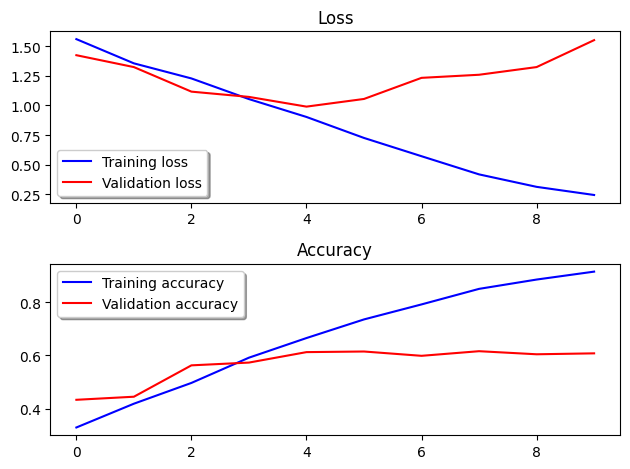

In [59]:
# Plot the loss and accuracy curves for training and validation
fig, ax = plt.subplots(2, 1)

# Loss
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="Validation loss")
ax[0].legend(loc='best', shadow=True)
ax[0].set_title("Loss")

# Accuracy
ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r', label="Validation accuracy")
ax[1].legend(loc='best', shadow=True)
ax[1].set_title("Accuracy")

plt.tight_layout()
plt.show()

In [61]:
# evaluate the model on the test data using 'evaluate'
print("Evaluate on test data")
results = model.evaluate(x_test, y_test, batch_size=128)
print("test loss, test acc:", results)

Evaluate on test data
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6076 - loss: 1.5494
test loss, test acc: [1.5494390726089478, 0.6076388955116272]


In [63]:
# print classification report
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis = 1)
y_true= np.argmax(y_test, axis =1)
print(classification_report(y_true, y_pred_classes))

27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 371ms/step
              precision    recall  f1-score   support

           0       0.59      0.61      0.60       162
           1       0.65      0.69      0.67       223
           2       0.53      0.35      0.42       155
           3       0.66      0.67      0.66       135
           4       0.58      0.67      0.62       189

    accuracy                           0.61       864
   macro avg       0.60      0.60      0.60       864
weighted avg       0.60      0.61      0.60       864



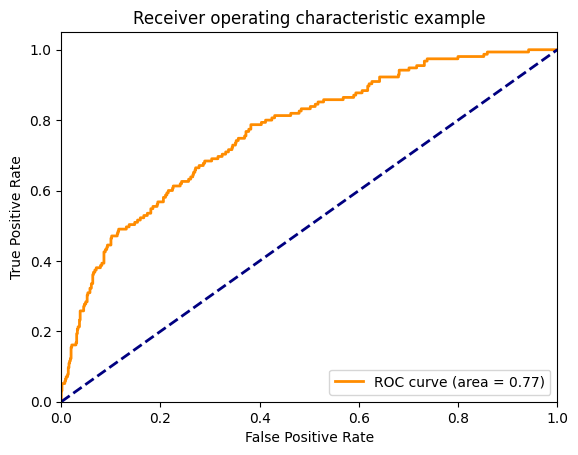

In [66]:
# plot roc curve
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(5):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
     
# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
 
plt.figure()
lw = 2
plt.plot(fpr[2], tpr[2], color='darkorange',
            lw=lw, label='ROC curve (area = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

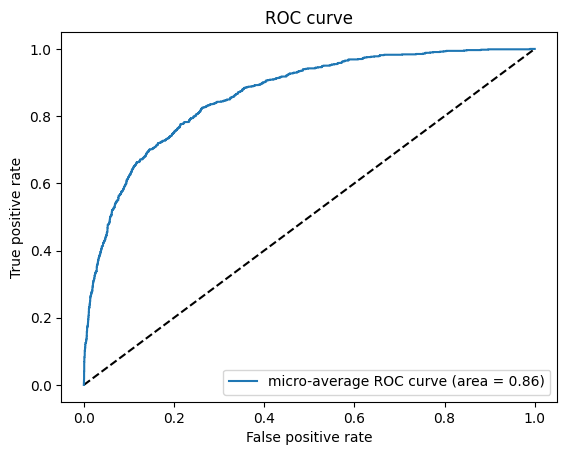

In [67]:
# plot auc curve
plt.figure()
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr["micro"], tpr["micro"], label='micro-average ROC curve (area = {0:0.2f})'
                                        ''.format(roc_auc["micro"]))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

## Results 

The CNN achieves approximately 50% accuracy on the test set (5 flower classes). Training accuracy reaches ~83% by epoch 10, but validation accuracy plateaus around 50-54%, indicating overfitting. See notebook for classification reports and ROC curves.

